# Choosing the Embedding Dimension $d$ and the Number of Communities $K$  
## Combinatorial Laplacian embedding + k-means + modularity on Zachary's Karate Club

In this notebook we illustrate a simple, self-contained workflow for selecting:

1. the embedding dimension $d$, and  
2. the number of communities $K$,

using **spectral embedding** followed by **k-means** and **modularity**.

We keep the philosophy that **$d$ is a representation choice** and **$K$ is a clustering choice**:

1. Choose $d$ from a spectral truncation diagnostic.
2. Fix $d$, then choose $K$ by maximizing modularity among candidate clusterings.


In [21]:
# Core imports
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from networkx.algorithms.community.quality import modularity

# Reproducibility
SEED = 8
rng = np.random.default_rng(SEED)

print("SEED =", SEED)


SEED = 8


## 1. Load Zachary's Karate Club graph

- Nodes represent members of a karate club.
- Edges represent friendships.
- The `club` attribute provides a commonly used 2-way split (ground truth) for visualization only.


In [22]:
G = nx.karate_club_graph()
n = G.number_of_nodes()
m = G.number_of_edges()

club = nx.get_node_attributes(G, "club")
club_color = {"Mr. Hi": 0, "Officer": 1}
node_colors_gt = [club_color[club[i]] for i in range(n)]

## 2. Graph visualization (spring layout)

This is a visualization heuristic and is used only for intuition.


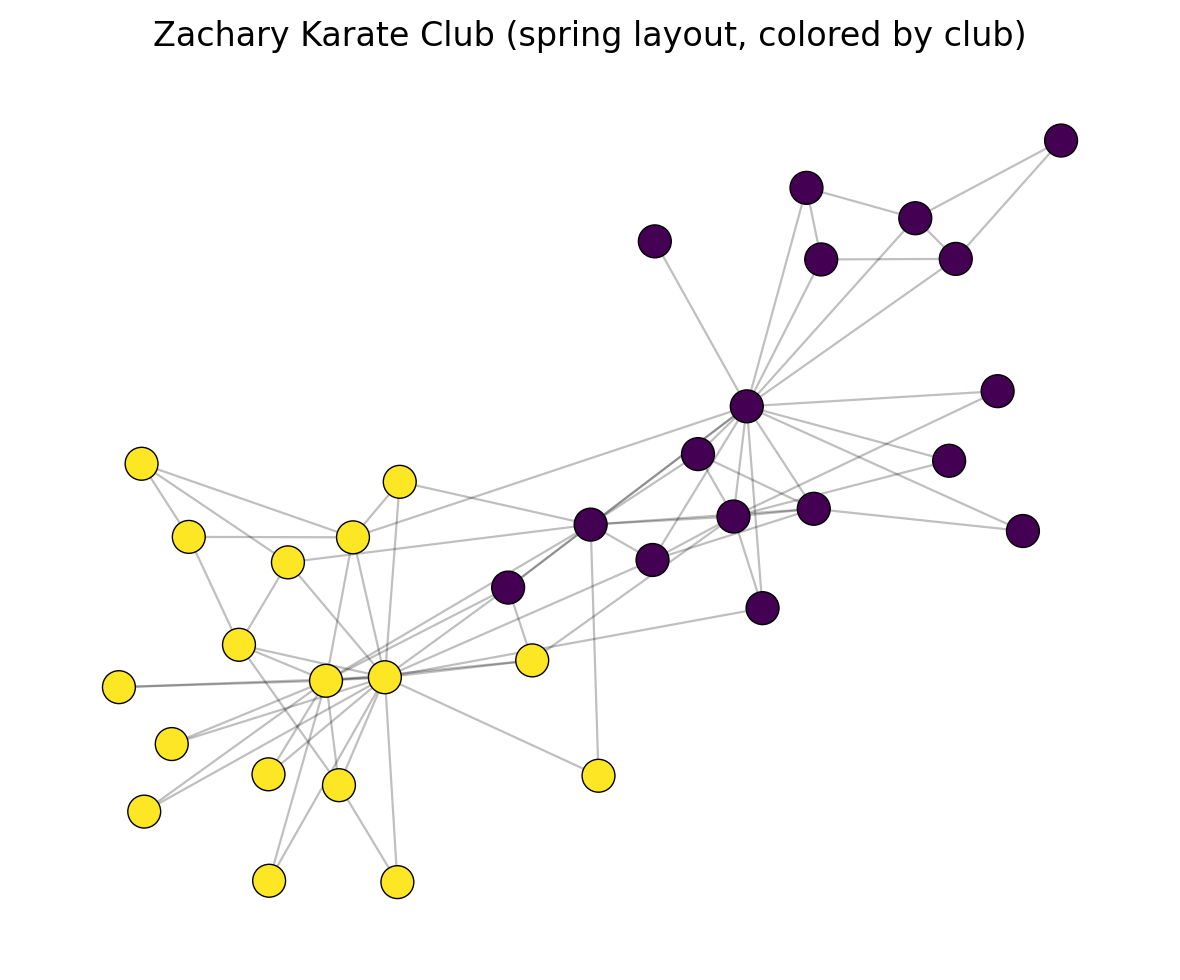

In [23]:
pos = nx.spring_layout(G, seed=SEED)

plt.figure(figsize=(6, 5), dpi=200)
nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.8)
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors_gt,
    node_size=140,
    edgecolors="black", linewidths=0.5
)
plt.title("Zachary Karate Club (spring layout, colored by club)")
plt.axis("off")
plt.tight_layout()
plt.show()


## 3. Build the combinatorial Laplacian $L=D-A$ and compute eigenpairs

Let $A=[a_{ij}]$ be the adjacency matrix and $D=\mathrm{diag}(d_1,\ldots,d_n)$ the degree matrix:
$$
d_i = \sum_{j=1}^{n} a_{ij}.
$$

The **combinatorial Laplacian** is
$$
L = D - A.
$$

For an undirected graph, $L$ is symmetric and has real eigenvalues:
$$
0 = \lambda_1 \le \lambda_2 \le \cdots \le \lambda_n.
$$

For a **connected** graph, $\lambda_1=0$ has eigenvector $\mathbf{1}$ (the constant vector), which is the trivial mode.
We discard this eigenvector and use the next eigenvectors to build embeddings.


In [24]:
# Adjacency and degree
A = nx.to_numpy_array(G, nodelist=range(n), dtype=float)
deg = A.sum(axis=1)
D = np.diag(deg)

# Combinatorial Laplacian
L = D - A

# Eigendecomposition (dense is fine for n=34)
evals, evecs = np.linalg.eigh(L)
idx = np.argsort(evals)
evals = evals[idx]
evecs = evecs[:, idx]

print("Smallest eigenvalues of L:", np.round(evals[:10], 6))


Smallest eigenvalues of L: [0.       1.187107 2.394319 2.93182  2.968302 3.061041 3.121263 3.706065
 3.800944 4.161606]


## 4. Choosing the embedding dimension $d$ (decoupled from $K$)

Before running k-means, we choose an embedding dimension $d$.

Here we want $d$ to be large enough so that the embedding captures most of the **geometry induced by the Laplacian pseudoinverse** $L^\dagger$, which is the object behind **resistance-type embeddings**. In this geometry, the contribution of eigenvector $v_k$ is weighted by $\lambda_k^{-1}$ (equivalently, coordinates scale as $1/\sqrt{\lambda_k}$). Therefore, a truncation rule based on the eigenvalues themselves can be misleading: large eigenvalues contribute little to $L^\dagger$, while small eigenvalues dominate.

For this reason, we define a *pseudoinverse-weighted* cumulative spectral mass:

$$
\mathrm{Mass}(d)
=
\frac{\sum_{k=2}^{d+1} \lambda_k^{-1}}{\sum_{k=2}^{n} \lambda_k^{-1}}.
$$

Interpretation:
- $\mathrm{Mass}(d)$ close to **1** means the first $d$ non-trivial eigenpairs capture most of the spectral contribution to $L^\dagger$ (hence most of the resistance geometry).
- Smaller values indicate that higher modes still contribute significantly to the pseudoinverse geometry.

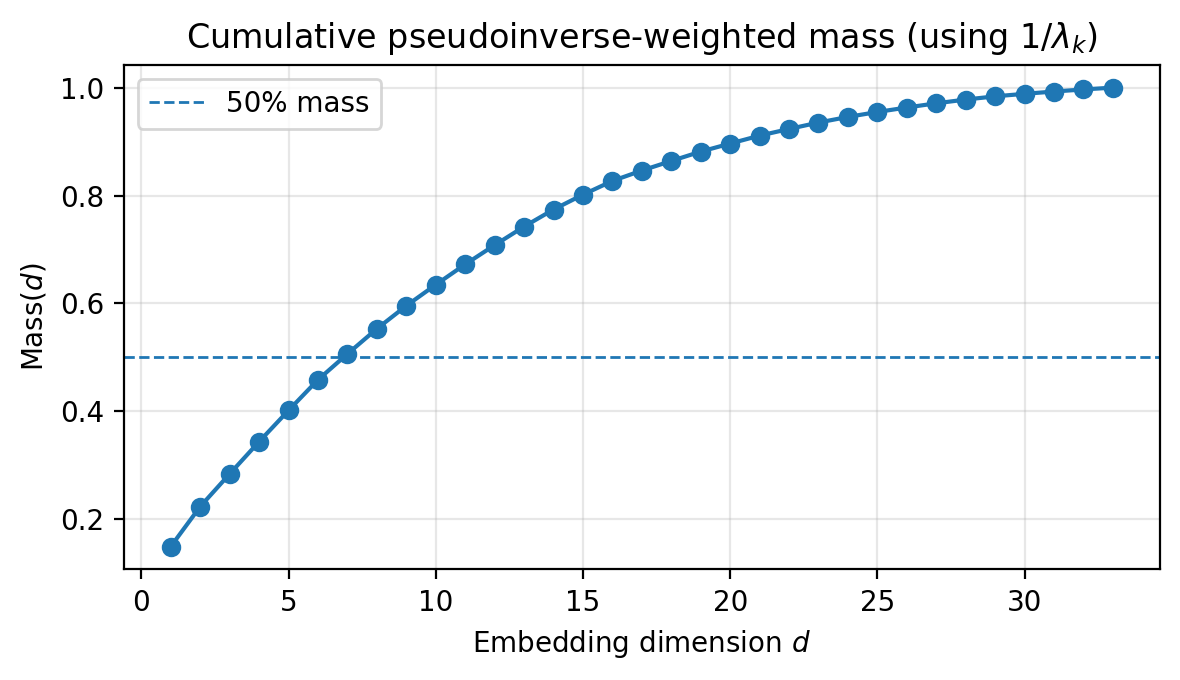

Chosen embedding dimension d* (Mass(d) ≥ 0.50): 7


In [25]:
# ------------------------------------------------------------
# Compute pseudoinverse-weighted spectral-mass diagnostic to choose embedding dimension d
# ------------------------------------------------------------

# Exclude the trivial eigenvalue lambda_1 = 0
lam = evals[1:]  # lambda_2,...,lambda_n

# Safety: avoid division by zero in case of numerical roundoff
eps = 1e-12
lam_safe = np.maximum(lam, eps)

# Pseudoinverse weights: 1/lambda_k
inv_lam = 1.0 / lam_safe

cum = np.cumsum(inv_lam)
mass = cum / cum[-1]

plt.figure(figsize=(6, 3.5), dpi=200)
plt.plot(range(1, len(inv_lam) + 1), mass, marker="o")

# 50% mass threshold
plt.axhline(0.50, linestyle="--", linewidth=1, label="50% mass")

plt.title("Cumulative pseudoinverse-weighted mass (using $1/\\lambda_k$)")
plt.xlabel("Embedding dimension $d$")
plt.ylabel(r"$\mathrm{Mass}(d)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Choose smallest d capturing at least 50% mass (and at least 2)
d_star = int(np.argmax(mass >= 0.50) + 1)
d_star = max(d_star, 2)

print("Chosen embedding dimension d* (Mass(d) ≥ 0.50):", d_star)

## 5. Build the $d$-dimensional spectral embedding (no row normalization)

Given $d=d^*$, we embed node $i$ using the next $d$ Laplacian eigenvectors
**scaled by the inverse square root of their eigenvalues**:

$$
\mathbf{x}_i =
\left(
\frac{u_2(i)}{\sqrt{\lambda_2}},
\ldots,
\frac{u_{d+1}(i)}{\sqrt{\lambda_{d+1}}}
\right)
\in \mathbb{R}^d .
$$

This scaling is important: it matches the **resistance-distance embedding**
derived from the Laplacian pseudoinverse.

Equivalently, defining

$$
X_d =
\begin{bmatrix}
\frac{u_2}{\sqrt{\lambda_2}} &
\cdots &
\frac{u_{d+1}}{\sqrt{\lambda_{d+1}}}
\end{bmatrix}
\in \mathbb{R}^{n\times d},
$$

the $i$-th row of $X_d$ is the coordinate vector of node $i$.

> Note: We intentionally do **not** apply row normalization in this notebook.

In [26]:
def laplacian_embedding_from_evecs(evals, evecs, d):
    """
    Build resistance-style spectral embedding.

    Coordinates:
        x_i = (u2(i)/sqrt(lambda2), ..., u_{d+1}(i)/sqrt(lambda_{d+1}))
    """

    lam = evals[1:d+1]              # lambda_2 ... lambda_{d+1}
    U = evecs[:, 1:d+1]             # eigenvectors u2 ... u_{d+1}

    # scale columns by 1/sqrt(lambda_k)
    scale = 1.0 / np.sqrt(lam)
    X = U * scale                   # broadcasting column scaling

    return X


X_d = laplacian_embedding_from_evecs(evals, evecs, d=d_star)

print("Embedding shape (n x d):", X_d.shape)
print("First 5 rows of embedding:")
print(np.round(X_d[:5], 4))

Embedding shape (n x d): (34, 7)
First 5 rows of embedding:
[[ 0.1132  0.0398 -0.0082 -0.0037 -0.0008 -0.0052 -0.0146]
 [ 0.0532  0.0848  0.0198  0.0175 -0.0063 -0.0297 -0.0453]
 [ 0.0126  0.0521  0.0241 -0.0042 -0.0083 -0.0238 -0.0154]
 [ 0.0683  0.107   0.032   0.0091 -0.0214 -0.1003  0.0297]
 [ 0.2454 -0.106   0.0064  0.0027  0.0005  0.0025 -0.0024]]


### 5.1 Visualize the embedding (first two coordinates)

Our resistance-style spectral embedding lives in $\mathbb{R}^d$ and uses the scaled eigenvector coordinates
$\mathbf{x}_i = \big(u_2(i)/\sqrt{\lambda_2},\ldots,u_{d+1}(i)/\sqrt{\lambda_{d+1}}\big)$.

For visualization, we plot only the first two coordinates $(x_1,x_2)$.
Even when $d>2$, the clustering step (k-means) is performed in the full $\mathbb{R}^d$ embedding.

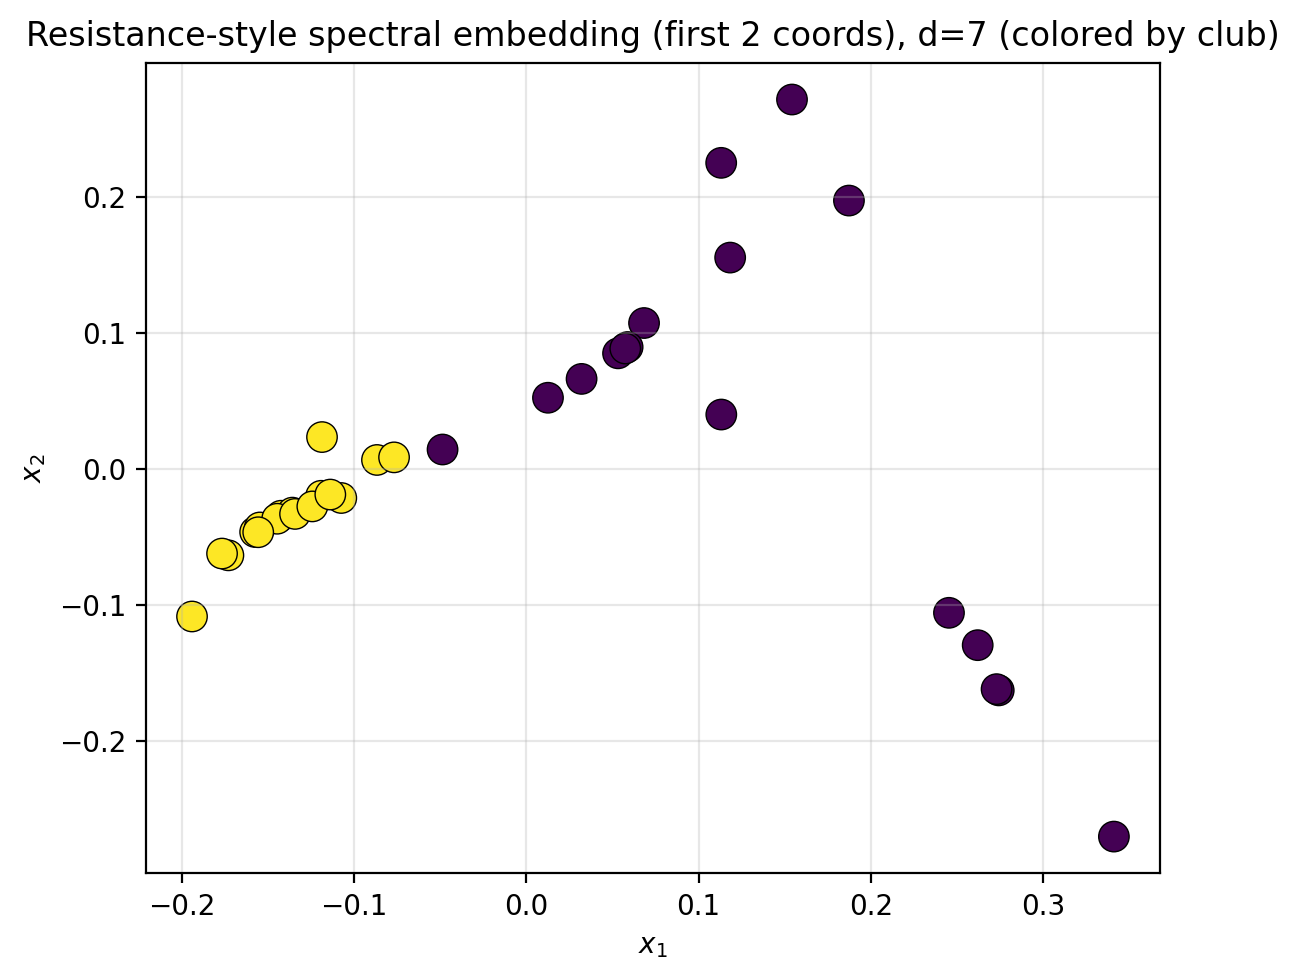

In [27]:
plt.figure(figsize=(6, 5), dpi=200)

plt.scatter(
    X_d[:, 0], X_d[:, 1],
    c=node_colors_gt,
    s=120,
    edgecolors="black",
    linewidths=0.5
)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(
    f"Resistance-style spectral embedding (first 2 coords), d={d_star} "
    "(colored by club)"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Choosing the number of communities $K$ via modularity (with $d$ fixed)

At this stage the **embedding dimension $d$ has already been selected** using a spectral diagnostic.

The next step is to determine the **number of communities $K$**.

To do so, we proceed as follows:

1. For each candidate value of $K$, run **k-means clustering** in the spectral embedding space $\mathbb{R}^d$.
2. Convert the clustering labels into a partition of the nodes.
3. Compute the **modularity** $Q_{\mathcal G}$ of the resulting partition.

Recall that modularity measures how much the observed number of intra-community edges exceeds the expected number under a random graph model with the same degree sequence.

Formally,

$$
Q_{\mathcal G}(\mathcal C_1,\ldots,\mathcal C_K)
=
\frac{1}{2m}
\sum_{i,j}
\left(
a_{ij} - \frac{d_i d_j}{2m}
\right)
c_{ij}.
$$

We select the number of clusters as

$$
K^* = \arg\max_K Q(K).
$$

This procedure separates **representation learning (embedding)** from **model selection (choosing $K$)**.

In [28]:
# ------------------------------------------------------------
# Run k-means for different K and evaluate modularity
# ------------------------------------------------------------

def kmeans_partition(X, K, seed=SEED):
    """
    Run k-means in the spectral embedding space.

    Parameters
    ----------
    X : ndarray (n x d)
        Node embedding matrix
    K : int
        Number of clusters
    seed : int
        Random seed

    Returns
    -------
    labels : ndarray
        Cluster label for each node
    comms : list of sets
        Community partition as sets of nodes
    """

    km = KMeans(n_clusters=K, n_init=30, random_state=seed)
    labels = km.fit_predict(X)

    comms = [set(np.where(labels == k)[0]) for k in range(K)]

    return labels, comms


# Candidate numbers of communities
K_candidates = list(range(2, 11))

Q_vals = []
labels_by_K = {}

for K in K_candidates:

    labels, comms = kmeans_partition(X_d, K)

    Q = modularity(G, comms)

    Q_vals.append(Q)
    labels_by_K[K] = labels

# Best K
K_star = K_candidates[int(np.argmax(Q_vals))]

print("Chosen K* maximizing modularity (with d fixed):", K_star)
print("Maximum modularity value:", max(Q_vals))

Chosen K* maximizing modularity (with d fixed): 3
Maximum modularity value: 0.4345214669889994


### 6.1 Modularity curve $Q_{\mathcal{G}}(K)$

We now visualize the modularity score as a function of the number of clusters.

The optimal value $K^*$ corresponds to the **maximum of the modularity curve**.

In practice, the curve often increases initially and then stabilizes or decreases as communities become artificially fragmented.

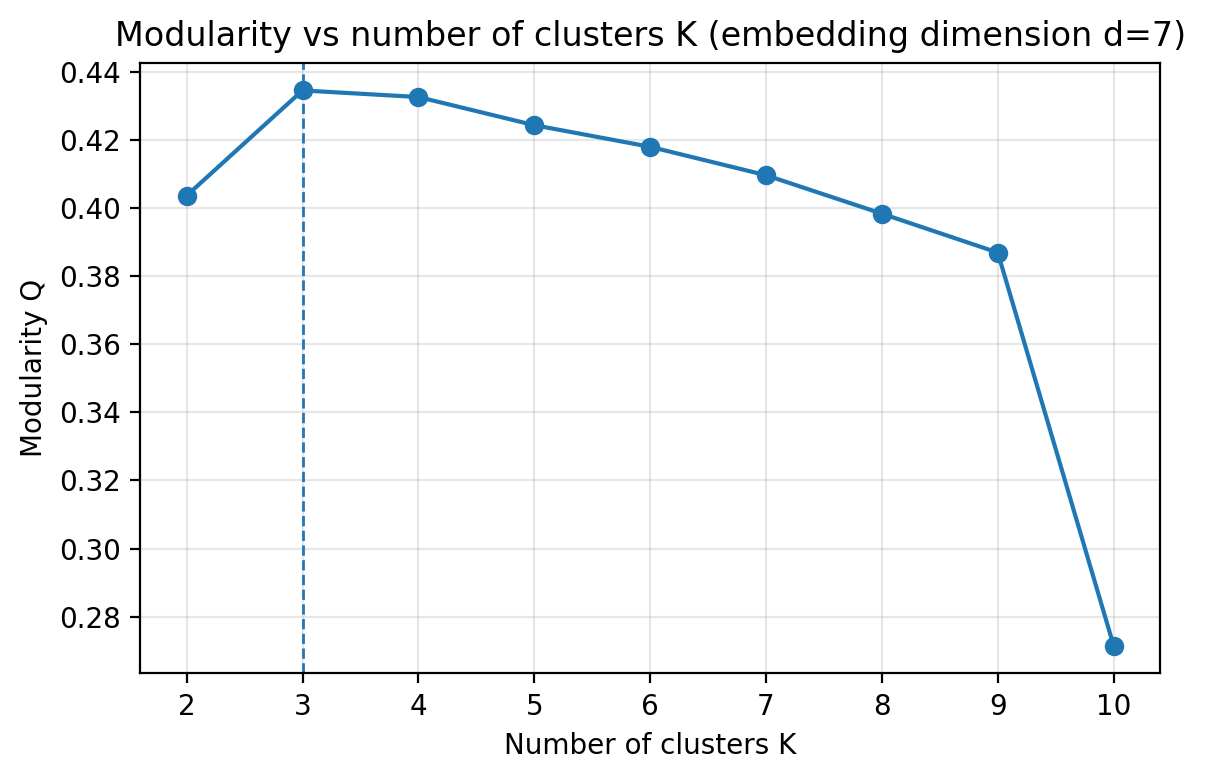

In [29]:
# ------------------------------------------------------------
# Plot modularity vs number of clusters
# ------------------------------------------------------------

plt.figure(figsize=(6,4), dpi=200)

plt.plot(K_candidates, Q_vals, marker="o")

plt.axvline(K_star, linestyle="--", linewidth=1)

plt.title(f"Modularity vs number of clusters K (embedding dimension d={d_star})")
plt.xlabel("Number of clusters K")
plt.ylabel("Modularity Q")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Visualizing the final clustering

Finally we visualize the detected community structure.

We show two complementary views:

1. The **original graph layout**, with nodes colored by the detected communities.
2. The **spectral embedding (first two coordinates)**, colored by the same labels.

Even when $d>2$, clustering is performed in the full $\mathbb{R}^d$ embedding.
The 2D plot simply provides an interpretable visualization.

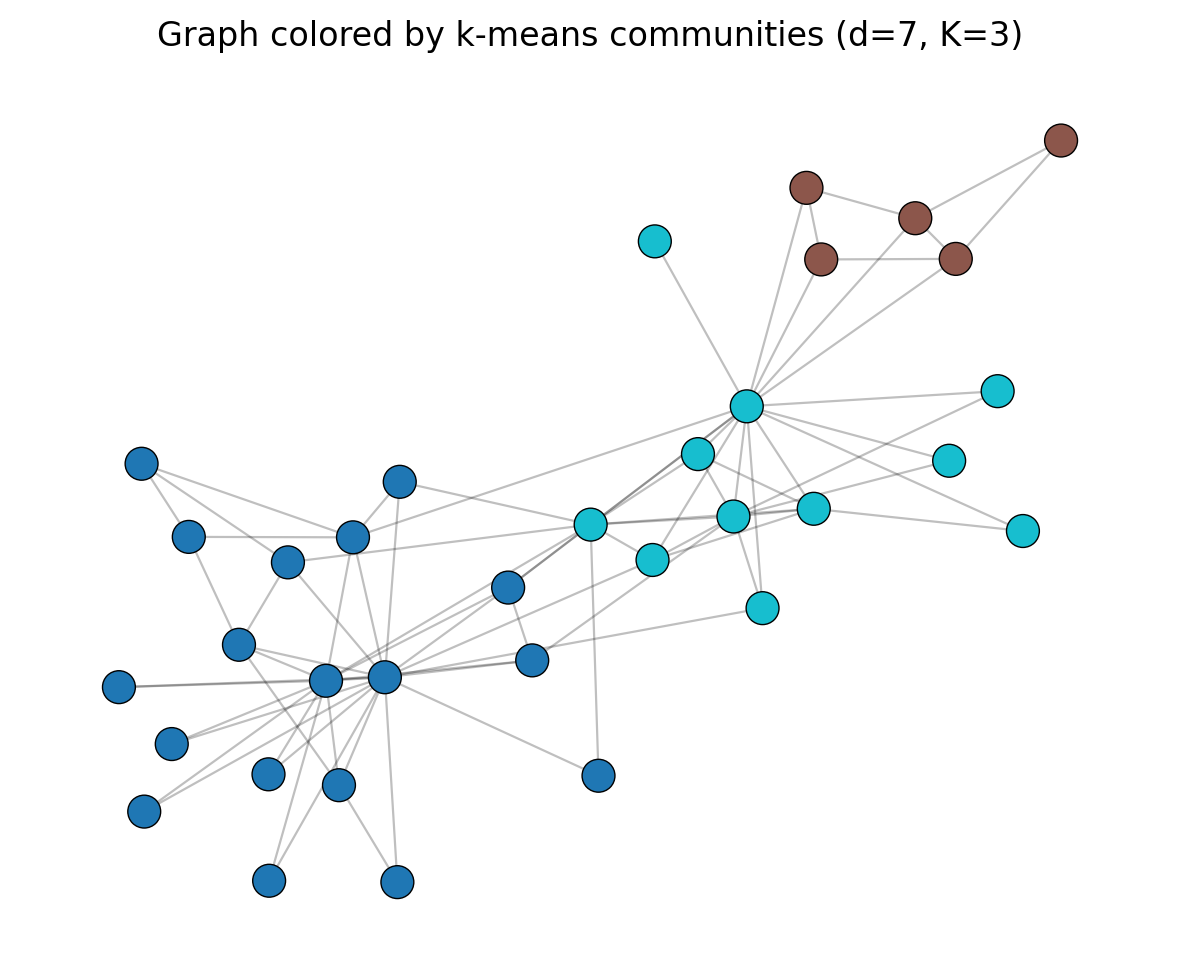

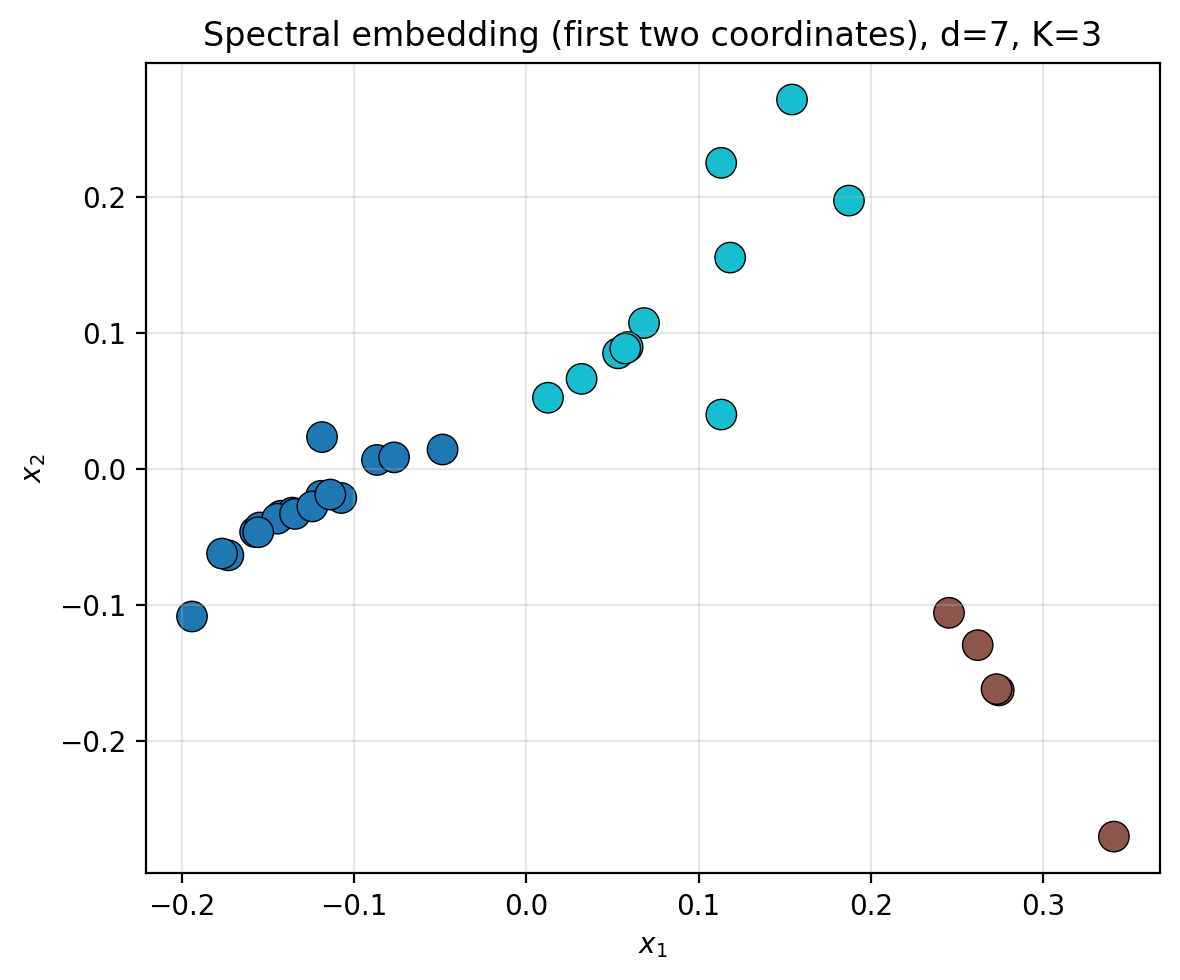

In [30]:
labels_star = labels_by_K[K_star]


# ------------------------------------------------------------
# Graph visualization
# ------------------------------------------------------------

plt.figure(figsize=(6,5), dpi=200)

nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.8)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=labels_star,
    node_size=140,
    edgecolors="black",
    linewidths=0.5,
    cmap=plt.cm.tab10
)

plt.title(f"Graph colored by k-means communities (d={d_star}, K={K_star})")

plt.axis("off")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Embedding visualization
# ------------------------------------------------------------

plt.figure(figsize=(6,5), dpi=200)

plt.scatter(
    X_d[:,0],
    X_d[:,1],
    c=labels_star,
    s=120,
    edgecolors="black",
    linewidths=0.5,
    cmap=plt.cm.tab10
)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")

plt.title(f"Spectral embedding (first two coordinates), d={d_star}, K={K_star}")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

In this notebook we illustrated the full **spectral clustering pipeline** using the Zachary Karate Club network.

Steps performed:

1. Constructed the **combinatorial Laplacian**
   $$L = D - A.$$

2. Computed its eigenpairs and used them to build a **spectral embedding**.

3. Selected the **embedding dimension $d$** using a spectral truncation diagnostic based on eigenvalue mass.

4. Constructed a resistance-style embedding
   $$
   \mathbf{x}_i =
   \left(
   \frac{u_2(i)}{\sqrt{\lambda_2}},\ldots,
   \frac{u_{d+1}(i)}{\sqrt{\lambda_{d+1}}}
   \right).
   $$

5. Determined the **number of communities $K$** by maximizing **modularity** over k-means partitions.

---

### Key takeaway

Spectral clustering naturally separates into two stages:

**Geometry learning**
→ build a low-dimensional embedding using the Laplacian spectrum.

**Community detection**
→ apply a clustering algorithm (e.g., k-means) and select the number of communities using modularity.